### 绘制数据集分布

In [46]:
import torch
import os
# 加载数据
# kcat
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_base import predict

kineticsType = "km"
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-1/model/pre-train-trainR2:0.9161-devR2=0.6674-RMSE=0.8867-MAE=0.5639-epoch=100",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-1/model/pre-train-trainR2:0.8980-devR2=0.6307-RMSE=0.7941-MAE=0.5537-epoch=100",
    'kkm':"../../KKM/TrainInfo/models/initialTrain-MACCSKeys/ECFPKKmPredictor-trainR2:0.8893-devR2=0.6136-RMSE=1.1116-MAE=0.7944-epoch=100"
}

kcatPairInfo = torch.load(f"../Data/{kineticsType.upper()}TestPairInfo") + torch.load(f"../Data/{kineticsType.upper()}TrainPairInfo")
Real, Pre = predict(
                    kineticsType.upper(),
                    modelPath[kineticsType],
                    kcatPairInfo,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True if kineticsType != 'kkm' else False,
                    torch.device("cuda:1"),
                    "MACCSKeys"
                   )

log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████| 287/287 [00:37<00:00,  7.62it/s]


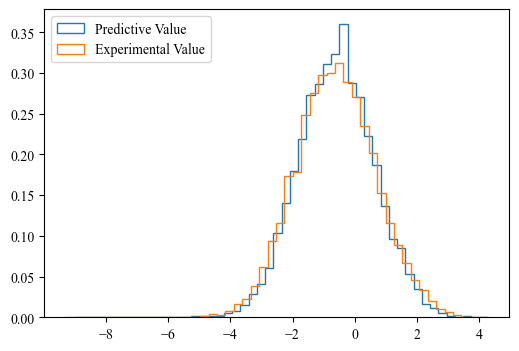

In [47]:
import matplotlib.pyplot as plt
from matplotlib import rc

Real = np.array(Real)
Pre = np.array(Pre)
if kineticsType == 'kkm':
    Real = np.log10(np.power(2, Real))
    Pre = np.log10(np.power(2, Pre))

plt.figure(figsize=(6,4))
a = plt.hist(Pre, bins=50, histtype='step', density=True, label='Predictive Value')
b = plt.hist(Real, bins=50, histtype='step', density=True, label='Experimental Value')
plt.legend(loc='best')

{'MAE': 0.4704119704141061, 'rmse': 0.7190102677891127, 'r2': -0.06117954053025243, 'r': 0.7001998731028803, 'p_value': 6.604790645587949e-125, 'samples': 841}
{'MAE': 0.36857700700982143, 'rmse': 0.5619312240490194, 'r2': -0.22714331812080113, 'r': 0.6445225500243345, 'p_value': 0.0, 'samples': 2950}
{'MAE': 0.2643689365510153, 'rmse': 0.38909285850134845, 'r2': 0.839516921656, 'r': 0.9192074034032343, 'p_value': 0.0, 'samples': 24873}


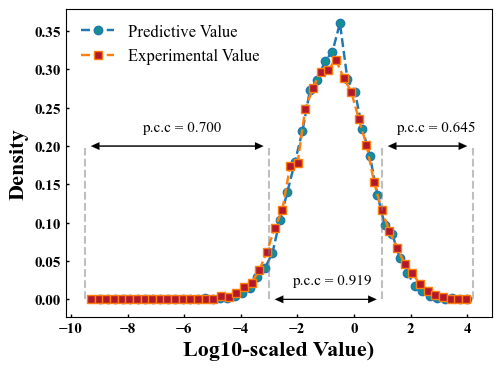

In [54]:
import numpy as np
plt.figure(figsize=(5.5,4))
rc('font',**{'family':'Times New Roman',})
plt.rcParams['pdf.fonttype'] = 42
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)
plt.plot(a[1][0:-1], a[0], label="Predictive Value",linestyle='dashed',linewidth=1.75,marker='o',markerfacecolor='#159090', markersize=6,)
plt.plot(b[1][0:-1], b[0], label="Experimental Value",linestyle='dashed',linewidth=1.75,marker='s',markerfacecolor='#b2182b', markersize=6,)

if kineticsType == 'km':
    y = np.arange(0, 0.2, 0.002)
    x1 = np.ones(100)*1
    x2 = np.ones(100)*-3

    x3 = np.ones(100)*4.2
    x4 = np.ones(100)*-9.5
    
    plt.arrow(-9, 0.2, 5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(-3.5, 0.2, -5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(3.7, 0.2, -2.2, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(1.5, 0.2, 2.2, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(-2.5, 0.0, 3, 0.0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(0.5, 0.0, -3, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
elif kineticsType == 'kkm':
    y = np.linspace(0, 0.16, 100)
    x1 = np.ones(100)*2.5
    x2 = np.ones(100)*-2.5

    x3 = np.ones(100)*9.5
    x4 = np.ones(100)*-9
    
    plt.arrow(-8.5, 0.16, 5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(-3, 0.16, -5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(9, 0.16, -6, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(3, 0.16, 6, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(-2, 0.0, 4, 0.0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(2, 0.0, -4, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

plt.plot(x1, y, linestyle='--', alpha=0.5, c='gray')
plt.plot(x2, y, linestyle='--', alpha=0.5, c='gray')
plt.plot(x3, y, linestyle='--', alpha=0.5, c='gray')
plt.plot(x4, y, linestyle='--', alpha=0.5, c='gray')

# plt.xlim(-10)

left = metric(Pre[Real<-3], Real[Real<-3], True)
print(left)
plt.text(-7.5, 0.22, f'p.c.c = {left["r"]:.3f}', fontweight ="normal", fontsize=11)
right = metric(Pre[Real>1], Real[Real>1], True)
print(right)
plt.text(1.5, 0.22, f'p.c.c = {right["r"]:.3f}', fontweight ="normal", fontsize=11)
middle = metric(Pre[(Real>=-3)&(Real<=1)], Real[(Real>=-3)&(Real<=1)], True)
print(middle)
plt.text(-2.2, 0.02, f'p.c.c = {middle["r"]:.3f}', fontweight ="normal", fontsize=11)

plt.rcParams['font.family'] = 'Times New Roman'
plt.xlabel('Log10-scaled Value)', fontsize=16, weight="bold")
plt.ylabel('Density', fontsize=16,weight="bold")
plt.xticks(fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.legend(frameon=False, prop={"size":12})
plt.savefig(f"../Fig/Fig5-MACCSKeys-{kineticsType}-distribution.png", dpi=600, bbox_inches='tight')

# iter8

In [1]:
import torch
import os
# 加载数据
# kcat
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_iter import predict

kineticsType = "kcat"
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9408-devR2=0.7459-RMSE=0.7751-MAE=0.4787-epoch=3",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9303-devR2=0.7163-RMSE=0.6960-MAE=0.4802-epoch=3",
    'kkm':"../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9188-devR2=0.8245-RMSE=0.7592-MAE=0.5030-epoch=4"
}

kcatPairInfo = torch.load(f"../Data/{kineticsType.upper()}TestPairInfo") + torch.load(f"../Data/{kineticsType.upper()}TrainPairInfo")
Real, Pre = predict(
                    kineticsType.upper(),
                    modelPath[kineticsType],
                    kcatPairInfo,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True,
                    torch.device("cuda:1"),
                    "MACCSKeys"
                   )

log10:True molType:MACCSKeys
F


100%|███████████████████████████████████████████████████████████| 345/345 [01:02<00:00,  5.53it/s]


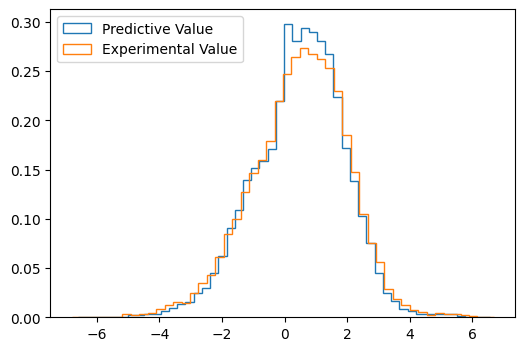

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np

Real = np.array(Real)
Pre = np.array(Pre)
# if kineticsType == 'kkm':
#     Real = np.log10(np.power(2, Real))
#     Pre = np.log10(np.power(2, Pre))

plt.figure(figsize=(6,4))
a = plt.hist(Pre, bins=50, histtype='step', density=True, label='Predictive Value')
b = plt.hist(Real, bins=50, histtype='step', density=True, label='Experimental Value')
plt.legend(loc='best')

{'MAE': 0.4505248333279712, 'rmse': 0.7308173723280328, 'r2': -0.17124207366859978, 'r': 0.7259893515939577, 'p_value': 3.2199161948867613e-103, 'samples': 624}
{'MAE': 0.36876050673234156, 'rmse': 0.6650699114237568, 'r2': 0.1531264060295624, 'r': 0.7341667765258735, 'p_value': 1.2673123747491786e-198, 'samples': 1170}
{'MAE': 0.20155228490966856, 'rmse': 0.35396517460578525, 'r2': 0.9266317203594016, 'r': 0.9626993484312726, 'p_value': 0.0, 'samples': 32635}


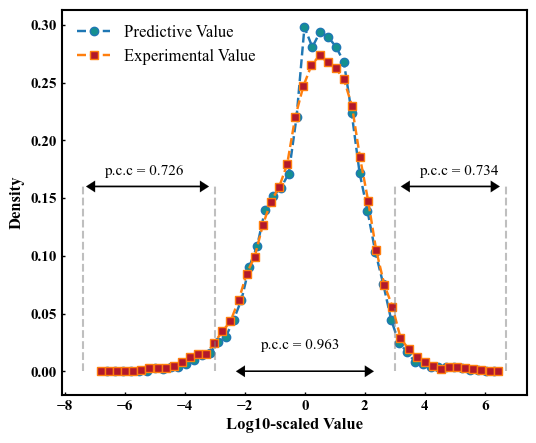

In [5]:
import numpy as np
plt.figure(figsize=(6,5))
rc('font',**{'family':'Times New Roman',})
plt.rcParams['pdf.fonttype'] = 42
plt.tick_params(direction='in')
plt.tick_params(which='major',length=2)
plt.tick_params(which='major',width=1)
plt.plot(a[1][0:-1], a[0], label="Predictive Value",linestyle='dashed',linewidth=1.75,marker='o',markerfacecolor='#159090', markersize=6,)
plt.plot(b[1][0:-1], b[0], label="Experimental Value",linestyle='dashed',linewidth=1.75,marker='s',markerfacecolor='#b2182b', markersize=6,)

if kineticsType == 'km':
    y = np.arange(0, 0.2, 0.002)
    x1 = np.ones(100)*1
    x2 = np.ones(100)*-3

    x3 = np.ones(100)*4.2
    x4 = np.ones(100)*-9.5
    
    plt.arrow(-9, 0.2, 5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(-3.5, 0.2, -5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(3.7, 0.2, -2.2, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(1.5, 0.2, 2.2, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(-2.5, 0.0, 3, 0.0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(0.5, 0.0, -3, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
elif kineticsType == 'kkm':
    y = np.linspace(0, 0.16, 100)
    x1 = np.ones(100)*2.5
    x2 = np.ones(100)*-2.5

    x3 = np.ones(100)*9.5
    x4 = np.ones(100)*-9
    
    plt.arrow(-8.5, 0.16, 5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(-3, 0.16, -5.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(9, 0.16, -6, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(3, 0.16, 6, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(-2, 0.0, 4, 0.0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(2, 0.0, -4, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

elif kineticsType == 'kcat':
    y = np.linspace(0, 0.16, 100)
    x1 = np.ones(100)*3
    x2 = np.ones(100)*-3

    x3 = np.ones(100)*6.7
    x4 = np.ones(100)*-7.4
    
    plt.arrow(-7.0, 0.16, 3.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(-3.5, 0.16, -3.5, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(6.2, 0.16, -2.7, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(3.5, 0.16, 2.7, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

    plt.arrow(-2, 0.0, 4, 0.0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)
    plt.arrow(2, 0.0, -4, 0, head_width=0.01, head_length=0.3, fc='black', ec='black',linewidth=0.1)

plt.plot(x1, y, linestyle='--', alpha=0.5, c='gray')
plt.plot(x2, y, linestyle='--', alpha=0.5, c='gray')
plt.plot(x3, y, linestyle='--', alpha=0.5, c='gray')
plt.plot(x4, y, linestyle='--', alpha=0.5, c='gray')

# plt.xlim(-10)
if kineticsType == 'km':
    left = metric(Pre[Real<-3], Real[Real<-3], True)
    print(left)
    plt.text(-7.5, 0.22, f'p.c.c = {left["r"]:.3f}', fontweight ="normal", fontsize=11)
    right = metric(Pre[Real>1], Real[Real>1], True)
    print(right)
    plt.text(1.5, 0.22, f'p.c.c = {right["r"]:.3f}', fontweight ="normal", fontsize=11)
    middle = metric(Pre[(Real>=-3)&(Real<=1)], Real[(Real>=-3)&(Real<=1)], True)
    print(middle)
    plt.text(-2.2, 0.02, f'p.c.c = {middle["r"]:.3f}', fontweight ="normal", fontsize=11)
elif kineticsType == 'kkm':
    left = metric(Pre[Real<-2.5], Real[Real<-2.5], True)
    print(left)
    plt.text(-7.5, 0.17, f'p.c.c = {left["r"]:.3f}', fontweight ="normal", fontsize=11)
    right = metric(Pre[Real>2.5], Real[Real>2.5], True)
    print(right)
    plt.text(4.5, 0.17, f'p.c.c = {right["r"]:.3f}', fontweight ="normal", fontsize=11)
    middle = metric(Pre[(Real>=-2.5)&(Real<=2.5)], Real[(Real>=-2.5)&(Real<=2.5)], True)
    print(middle)
    plt.text(-2.2, 0.02, f'p.c.c = {middle["r"]:.3f}', fontweight ="normal", fontsize=11)
elif kineticsType == 'kcat':
    left = metric(Pre[Real<-3], Real[Real<-3], True)
    print(left)
    plt.text(-6.7, 0.17, f'p.c.c = {left["r"]:.3f}', fontweight ="normal", fontsize=11)
    right = metric(Pre[Real>3], Real[Real>3], True)
    print(right)
    plt.text(3.8, 0.17, f'p.c.c = {right["r"]:.3f}', fontweight ="normal", fontsize=11)
    middle = metric(Pre[(Real>=-3)&(Real<=3)], Real[(Real>=-3)&(Real<=3)], True)
    print(middle)
    plt.text(-1.5, 0.02, f'p.c.c = {middle["r"]:.3f}', fontweight ="normal", fontsize=11)

plt.rcParams['font.family'] = 'Times New Roman'
plt.xlabel('Log10-scaled Value', fontsize=12, weight="bold")
plt.ylabel('Density', fontsize=12,weight="bold")
ax = plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
plt.xticks(fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.legend(frameon=False, prop={"size":12})
plt.savefig(f"../Fig/Fig5-iter8-MACCSKeys-{kineticsType}-distribution.png", dpi=600, bbox_inches='tight')